In [1]:
#taken from this starter notebook: https://www.kaggle.com/code/picekl/fungiclef25-starter-notebook
# !pip install -q git+https://github.com/mlfoundations/open_clip.git #openai clip, prerequisite for bioclip 

In [2]:
# import open_clip
# model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip')
# tokenizer = open_clip.get_tokenizer('hf-hub:imageomics/bioclip')

In [3]:
# install pybioclip 
!pip install pybioclip ipywidgets --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00


In [4]:
import numpy as np 
import pandas as pd 
import requests #  download images
import shutil #  open images 
import PIL.Image, PIL.ImageOps # to view images
import matplotlib.pyplot as plt
import ast #for handling lists (bounding boxes)
import tempfile #temp save cropped image for testing
#python package that simplifies using BioCLIP for predictions
from bioclip import TreeOfLifeClassifier, Rank
from IPython.display import display #see image
import cv2 as cv #for clahe


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/train-metadata/train_joined_metadata.csv


- Follow steps in this [notebook](https://github.com/Imageomics/pybioclip/blob/main/examples/PredictImages.ipynb) that explains how to use [pybioclip](https://github.com/Imageomics/pybioclip/tree/main), using some sample images from our data

- pybioclip [documentation](https://imageomics.github.io/pybioclip/)

 

# Try BioCLIP some sample images from our train set (no fine-tuning)

In [5]:
train_metadata = pd.read_csv("/kaggle/input/train-metadata/train_joined_metadata.csv")
train_metadata.head()

,id_annotation_image_id,image_id,category_id,area,bbox,width,height,file_name,coco_url,date_captured,name
0,1,1,71,943.0,"[491.0, 254.0, 23.0, 41.0]",720,368,67cda248-6d28-4801-9c4e-e4525189ea38.png,https://database.fathomnet.org/static/m3/frame...,2008-12-19 19:46:56,Sebastolobus
1,2,2,8,71577.0,"[701.0, 505.0, 241.0, 297.0]",1920,1080,d9b399f3-8628-4138-a339-f4520be751c5.png,https://database.fathomnet.org/static/m3/frame...,2019-05-30 16:41:04,Apostichopus leukothele
2,3,3,67,533148.0,"[458.0, 332.0, 924.0, 577.0]",1920,1080,3289c3e1-40f2-4512-992f-3fa406b50a86.png,https://database.fathomnet.org/static/m3/frame...,2014-06-05 20:04:19,Scotoplanes
3,4,4,37,299186.0,"[1155.0, 71.0, 659.0, 454.0]",1920,1080,801dc37d-1aac-49ac-9067-93ae4bb7c8b6.png,https://database.fathomnet.org/static/m3/frame...,2017-12-21 15:37:28,Keratoisis
4,5,4,37,520650.0,"[66.0, 6.0, 975.0, 534.0]",1920,1080,801dc37d-1aac-49ac-9067-93ae4bb7c8b6.png,https://database.fathomnet.org/static/m3/frame...,2017-12-21 15:37:28,Keratoisis


In [6]:
# get first five images 
IMAGE_NAMES = train_metadata.iloc[:5, train_metadata.columns.get_loc('name')].values.tolist()
print(IMAGE_NAMES)
IMAGE_URLS = train_metadata.iloc[:5, train_metadata.columns.get_loc('coco_url')].values.tolist()
print(IMAGE_URLS)
IMAGE_DIR = "images"
THUMBNAIL_SIZE = (256,256)

['Sebastolobus', 'Apostichopus leukothele', 'Scotoplanes', 'Keratoisis', 'Keratoisis']
['https://database.fathomnet.org/static/m3/framegrabs/Ventana/images/3317/01_17_26_19.png', 'https://database.fathomnet.org/static/m3/framegrabs/Ventana/images/4194/20190530T164104Z-60628e6f-6398-4267-9757-288078efec28.png', 'https://database.fathomnet.org/static/m3/framegrabs/Doc%20Ricketts/images/0617/01_43_19_24.png', 'https://database.fathomnet.org/static/m3/framegrabs/Doc%20Ricketts/images/1000/00_49_08_07.png', 'https://database.fathomnet.org/static/m3/framegrabs/Doc%20Ricketts/images/1000/00_49_08_07.png']


In [7]:
def download_image(url, filename):
    os.makedirs(IMAGE_DIR, exist_ok=True)
    path = os.path.join(IMAGE_DIR, filename)
    response = requests.get(url, stream=True)
    response.raise_for_status()
    with open(path, 'wb') as out_file:
        shutil.copyfileobj(response.raw, out_file)
    return path

# Ensure IMAGE_NAMES and IMAGE_URLS have the same length
if len(IMAGE_NAMES) != len(IMAGE_URLS):
    raise ValueError("The number of image names must match the number of image URLs.")

# Download images using the names from IMAGE_NAMES
image_paths = [download_image(url, name) for url, name in zip(IMAGE_URLS, IMAGE_NAMES)]

print("Image paths:")
print(image_paths)

Image paths:
['images/Sebastolobus', 'images/Apostichopus leukothele', 'images/Scotoplanes', 'images/Keratoisis', 'images/Keratoisis']


In [8]:

classifier = TreeOfLifeClassifier(device='cpu')

# create a dictionary with predictions that includes whole taxonomy plus score
prediction_ary = classifier.predict(image_paths, rank=Rank.SPECIES)

# turn into pandas dataframe for ease of use
df_species = pd.DataFrame(prediction_ary)
df_species

open_clip_pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

open_clip_config.json:   0%|          | 0.00/469 [00:00<?, ?B/s]

txt_emb_species.npy:   0%|          | 0.00/787M [00:00<?, ?B/s]

txt_emb_species.json:   0%|          | 0.00/65.7M [00:00<?, ?B/s]

100%|██████████| 5/5 [00:02<00:00,  2.17images/s]


,file_name,kingdom,phylum,class,order,family,genus,species_epithet,species,common_name,score
0,images/Sebastolobus,Animalia,Porifera,Hexactinellida,Lyssacinosida,Rossellidae,Anoxycalyx,joubini,Anoxycalyx joubini,volcano sponge,0.129768
1,images/Sebastolobus,Animalia,Cnidaria,Anthozoa,Alcyonacea,Primnoidae,Fannyella,abies,Fannyella abies,,0.050318
2,images/Sebastolobus,Animalia,Porifera,Hexactinellida,Amphidiscosida,Hyalonematidae,Hyalonema,rapa,Hyalonema rapa,,0.041163
3,images/Sebastolobus,Animalia,Chordata,Actinopterygii,Caproiformes,Caproidae,Antigonia,rubescens,Antigonia rubescens,boarfish,0.040411
4,images/Sebastolobus,Animalia,Mollusca,Bivalvia,Pectinida,Pectinidae,Delectopecten,vancouverensis,Delectopecten vancouverensis,Vancouver scallop,0.030401
5,images/Apostichopus leukothele,Animalia,Chordata,Ascidiacea,Phlebobranchia,Ascidiidae,Ascidia,linnaeus,Ascidia linnaeus,,0.376993
6,images/Apostichopus leukothele,Animalia,Cnidaria,Anthozoa,Alcyonacea,Alcyoniidae,Anthomastus,verrill,Anthomastus verrill,,0.161309
7,images/Apostichopus leukothele,Animalia,Echinodermata,Holothuroidea,Synallactida,Stichopodidae,Apostichopus,leukothele,Apostichopus leukothele,white-knobbed sea cucumber,0.147428
8,images/Apostichopus leukothele,Animalia,Echinodermata,Holothuroidea,Synallactida,Stichopodidae,Apostichopus,californicus,Apostichopus californicus,giant California sea cucumber,0.079879
9,images/Apostichopus leukothele,Animalia,Mollusca,Gastropoda,Nudibranchia,Arminidae,Dermatobranchus,phyllodes,Dermatobranchus phyllodes,,0.042598


# Display one image and predictions

'images/Apostichopus leukothele'

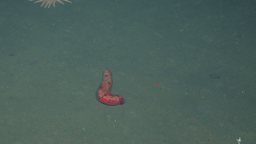

,file_name,kingdom,phylum,class,order,family,genus,species_epithet,species,common_name,score
5,images/Apostichopus leukothele,Animalia,Chordata,Ascidiacea,Phlebobranchia,Ascidiidae,Ascidia,linnaeus,Ascidia linnaeus,,0.376993
6,images/Apostichopus leukothele,Animalia,Cnidaria,Anthozoa,Alcyonacea,Alcyoniidae,Anthomastus,verrill,Anthomastus verrill,,0.161309
7,images/Apostichopus leukothele,Animalia,Echinodermata,Holothuroidea,Synallactida,Stichopodidae,Apostichopus,leukothele,Apostichopus leukothele,white-knobbed sea cucumber,0.147428
8,images/Apostichopus leukothele,Animalia,Echinodermata,Holothuroidea,Synallactida,Stichopodidae,Apostichopus,californicus,Apostichopus californicus,giant California sea cucumber,0.079879
9,images/Apostichopus leukothele,Animalia,Mollusca,Gastropoda,Nudibranchia,Arminidae,Dermatobranchus,phyllodes,Dermatobranchus phyllodes,,0.042598


In [9]:
example_image_path = image_paths[1]
image = PIL.Image.open(example_image_path)
image.thumbnail(THUMBNAIL_SIZE)
display(example_image_path)
display(image)
df_species[df_species['file_name'] == example_image_path]

## Predict from a list of classes

In [10]:
from bioclip import CustomLabelsClassifier


In [11]:
# we could use all of the common names found in fathomnet as custom labels 
classifier = CustomLabelsClassifier(["anemone","coral","whale"])

# create a dictionary with predictions that includes whole taxonomy plus score
prediction_ary = classifier.predict(image_paths)

df_custom = pd.DataFrame(prediction_ary)
df_custom


100%|██████████| 5/5 [00:01<00:00,  2.61images/s]


,file_name,classification,score
0,images/Sebastolobus,coral,0.649406
1,images/Sebastolobus,whale,0.224957
2,images/Sebastolobus,anemone,0.125637
3,images/Apostichopus leukothele,whale,0.991794
4,images/Apostichopus leukothele,coral,0.007046
5,images/Apostichopus leukothele,anemone,0.001159
6,images/Scotoplanes,whale,0.970140
7,images/Scotoplanes,coral,0.029757
8,images/Scotoplanes,anemone,0.000103
9,images/Keratoisis,coral,0.455116


# Crop images to bounding box size and predict

'images/Apostichopus leukothele'

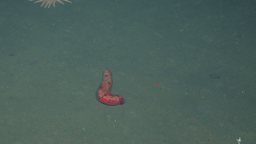

In [12]:
example_image_path = image_paths[1]
image = PIL.Image.open(example_image_path)
image.thumbnail(THUMBNAIL_SIZE)
display(example_image_path)
display(image)


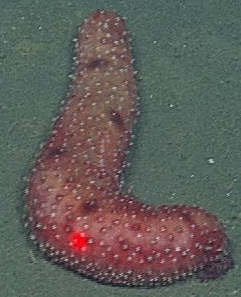

In [13]:
#  bbox format: [x, y, width, height]

# Open the image
example_image_path = image_paths[1]
image = PIL.Image.open(example_image_path)

# Define bounding box coordinates
bbox = train_metadata.iloc[1:2, train_metadata.columns.get_loc('bbox')].values.tolist()[0]
bbox = ast.literal_eval(bbox)
x, y, w, h = map(int, bbox)

right = x + w
lower = y + h

# Ensure valid coordinates
width = train_metadata.iloc[1:2, train_metadata.columns.get_loc('width')].values.tolist()[0]
height = train_metadata.iloc[1:2, train_metadata.columns.get_loc('height')].values.tolist()[0]

left = max(0, x)
upper = max(0, y)
right = min(right, width)  
lower = min(lower, height)

# Verify coordinate order
if right <= left or lower <= upper:
    raise ValueError(f"Invalid coordinates: ({left}, {upper}, {right}, {lower})")

# Crop and save
with PIL.Image.open(example_image_path) as img:
    cropped_img = img.crop((left, upper, right, lower))

with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
    cropped_img.save(tmp.name)
    temp_path = tmp.name

# display
display(cropped_img)

## Prediction with whole image

In [14]:
# whole image
classifier = TreeOfLifeClassifier(device='cpu')

# create a dictionary with predictions that includes whole taxonomy plus score
prediction_ary = classifier.predict(example_image_path, rank=Rank.SPECIES)

# turn into pandas dataframe for ease of use
df_species = pd.DataFrame(prediction_ary)
df_species

100%|██████████| 1/1 [00:00<00:00,  2.25images/s]


,file_name,kingdom,phylum,class,order,family,genus,species_epithet,species,common_name,score
0,images/Apostichopus leukothele,Animalia,Chordata,Ascidiacea,Phlebobranchia,Ascidiidae,Ascidia,linnaeus,Ascidia linnaeus,,0.376991
1,images/Apostichopus leukothele,Animalia,Cnidaria,Anthozoa,Alcyonacea,Alcyoniidae,Anthomastus,verrill,Anthomastus verrill,,0.161309
2,images/Apostichopus leukothele,Animalia,Echinodermata,Holothuroidea,Synallactida,Stichopodidae,Apostichopus,leukothele,Apostichopus leukothele,white-knobbed sea cucumber,0.147429
3,images/Apostichopus leukothele,Animalia,Echinodermata,Holothuroidea,Synallactida,Stichopodidae,Apostichopus,californicus,Apostichopus californicus,giant California sea cucumber,0.079879
4,images/Apostichopus leukothele,Animalia,Mollusca,Gastropoda,Nudibranchia,Arminidae,Dermatobranchus,phyllodes,Dermatobranchus phyllodes,,0.042599


## Prediction with cropped image

- Correct label is now top-1

In [15]:

# cropped image
classifier = TreeOfLifeClassifier(device='cpu')

# create a dictionary with predictions that includes whole taxonomy plus score
prediction_ary = classifier.predict(temp_path, rank=Rank.SPECIES)

# turn into pandas dataframe for ease of use
df_species = pd.DataFrame(prediction_ary)
df_species

100%|██████████| 1/1 [00:00<00:00,  2.57images/s]


,file_name,kingdom,phylum,class,order,family,genus,species_epithet,species,common_name,score
0,/tmp/tmpwzahi3f2.jpg,Animalia,Echinodermata,Holothuroidea,Synallactida,Stichopodidae,Apostichopus,leukothele,Apostichopus leukothele,white-knobbed sea cucumber,0.219988
1,/tmp/tmpwzahi3f2.jpg,Animalia,Echinodermata,Holothuroidea,Holothuriida,Mesothuriidae,Mesothuria,verrilli,Mesothuria verrilli,,0.127944
2,/tmp/tmpwzahi3f2.jpg,Animalia,Echinodermata,Holothuroidea,Holothuriida,Mesothuriidae,Mesothuria,maroccana,Mesothuria maroccana,,0.120726
3,/tmp/tmpwzahi3f2.jpg,Animalia,Echinodermata,Holothuroidea,Synallactida,Stichopodidae,Parastichopus,regalis,Parastichopus regalis,royal cucumber,0.088133
4,/tmp/tmpwzahi3f2.jpg,Animalia,Echinodermata,Holothuroidea,Elasipodida,Psychropotidae,Psychropotes,longicauda,Psychropotes longicauda,Gummy Squirrel,0.036526


# Red channel only

- Really confuses the classifier

(-0.5, 240.5, 296.5, -0.5)

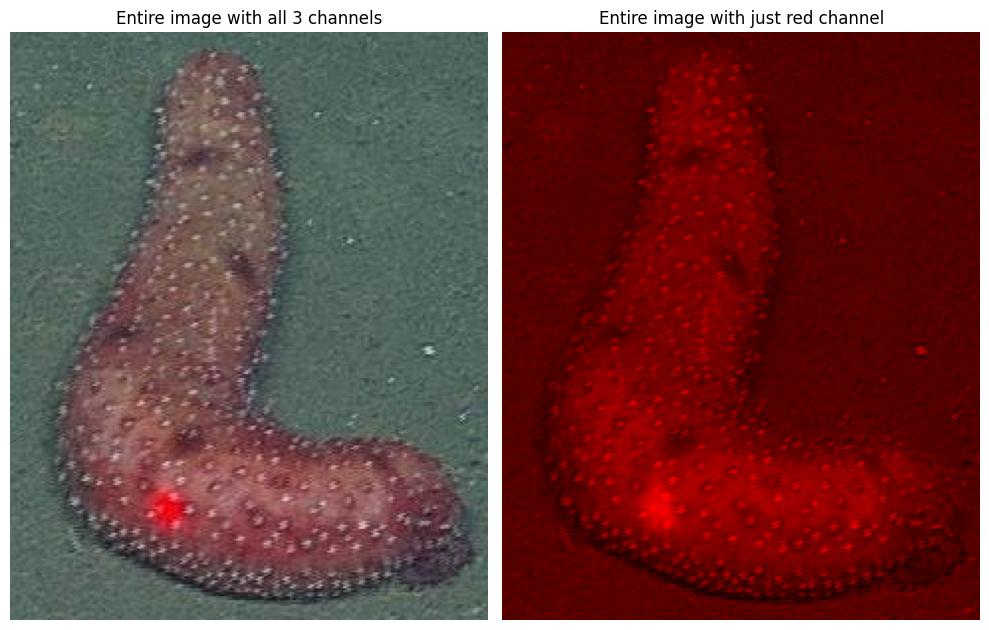

In [16]:
img_mono =  plt.imread(f"{temp_path}")
img_mono.shape

#set blue and green channels to 0
img_mono_copy = img_mono.copy()
img_mono_copy[:,:,1] = 0
img_mono_copy[:,:,2] = 0

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 10), tight_layout=True)
axs[0].imshow(img_mono)
axs[0].set_title("Entire image with all 3 channels")
axs[0].axis("off")

axs[1].imshow(img_mono_copy, cmap="gray")
axs[1].set_title("Entire image with just red channel")
axs[1].axis("off")

In [17]:
# Convert numpy array to PIL Image
img_red = PIL.Image.fromarray(img_mono_copy.astype('uint8'), 'RGB')

# Save as JPEG
img_red.save('output_red.jpeg', 'JPEG')

In [18]:
classifier = TreeOfLifeClassifier(device='cpu')

# Use the saved JPEG for classification
prediction_ary = classifier.predict('output_red.jpeg', rank=Rank.SPECIES)

# Convert to pandas dataframe
df_species = pd.DataFrame(prediction_ary)
df_species

100%|██████████| 1/1 [00:00<00:00,  2.45images/s]


,file_name,kingdom,phylum,class,order,family,genus,species_epithet,species,common_name,score
0,output_red.jpeg,Bacteria,Cyanobacteria,Cyanophyceae,Nostocales,Nostocaceae,Cylindrospermum,muscicola,Cylindrospermum muscicola,,0.150951
1,output_red.jpeg,Protozoa,Protozoa,Lobosa,Amoebida,Entamoebidae,Entamoeba,coli,Entamoeba coli,,0.146825
2,output_red.jpeg,Animalia,Porifera,Demospongiae,Poecilosclerida,Coelosphaeridae,Lepidosphaera,hindei,Lepidosphaera hindei,,0.050046
3,output_red.jpeg,Animalia,Porifera,Calcarea,Leucosolenida,Heteropiidae,Heteropia,minor,Heteropia minor,,0.049163
4,output_red.jpeg,Protozoa,Protozoa,Heterotrichea,Heterotrichida,Stentoridae,Stentor,fuliginosus,Stentor fuliginosus,,0.042168


# Grayscale

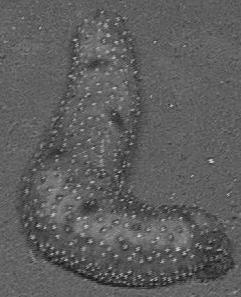

In [19]:
# save numpy to jpeg
img_mono_img = PIL.Image.fromarray(img_mono.astype('uint8'), 'RGB')
img_mono_img.save('img_mono.jpeg', 'JPEG')

#convert to grayscale
im1 = PIL.Image.open('/kaggle/working/img_mono.jpeg') 
im2 = PIL.ImageOps.grayscale(im1) 


display(im2)


In [20]:
classifier = TreeOfLifeClassifier(device='cpu')

# Use the saved JPEG for classification
prediction_ary = classifier.predict('/kaggle/working/img_mono.jpeg', rank=Rank.SPECIES)

# Convert to pandas dataframe
df_species = pd.DataFrame(prediction_ary)
df_species

100%|██████████| 1/1 [00:00<00:00,  2.24images/s]


,file_name,kingdom,phylum,class,order,family,genus,species_epithet,species,common_name,score
0,/kaggle/working/img_mono.jpeg,Animalia,Echinodermata,Holothuroidea,Synallactida,Stichopodidae,Apostichopus,leukothele,Apostichopus leukothele,white-knobbed sea cucumber,0.220310
1,/kaggle/working/img_mono.jpeg,Animalia,Echinodermata,Holothuroidea,Holothuriida,Mesothuriidae,Mesothuria,verrilli,Mesothuria verrilli,,0.130026
2,/kaggle/working/img_mono.jpeg,Animalia,Echinodermata,Holothuroidea,Holothuriida,Mesothuriidae,Mesothuria,maroccana,Mesothuria maroccana,,0.125721
3,/kaggle/working/img_mono.jpeg,Animalia,Echinodermata,Holothuroidea,Synallactida,Stichopodidae,Parastichopus,regalis,Parastichopus regalis,royal cucumber,0.086208
4,/kaggle/working/img_mono.jpeg,Animalia,Echinodermata,Holothuroidea,Elasipodida,Psychropotidae,Psychropotes,longicauda,Psychropotes longicauda,Gummy Squirrel,0.036468


# Apply CLAHE + grayscale

In [21]:
#using cv2 to convert to grayscale

img = cv.imread(temp_path, cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
 

clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl1 = clahe.apply(img)
 
cv.imwrite('clahe_2.jpg',cl1)

True

Check histogram before CLAHE

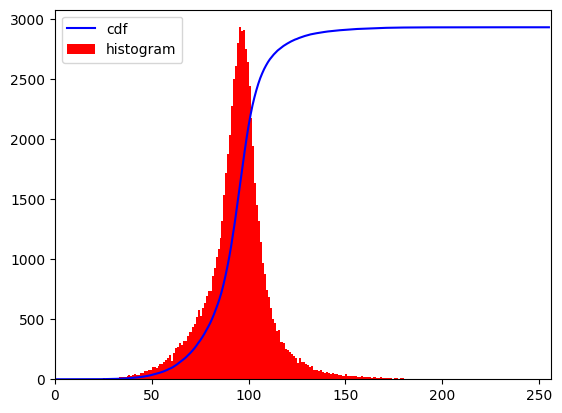

In [22]:
#check histogram before clahe
hist,bins = np.histogram(img.flatten(),256,[0,256])
 
cdf = hist.cumsum()
cdf_normalized = cdf * float(hist.max()) / cdf.max()
 
plt.plot(cdf_normalized, color = 'b')
plt.hist(img.flatten(),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')
plt.show()

and after CLAHE

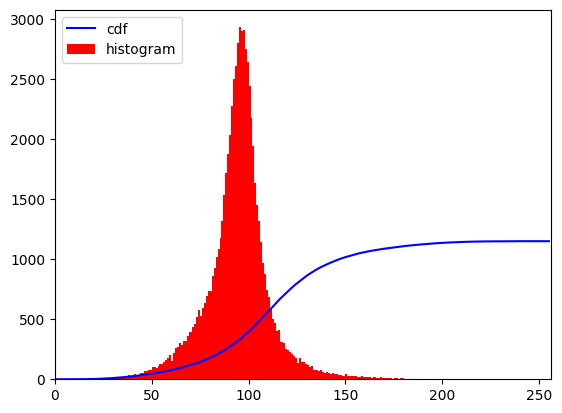

In [23]:
#check histogram
hist,bins = np.histogram(cl1.flatten(),256,[0,256])
 
cdf = hist.cumsum()
cdf_normalized = cdf * float(hist.max()) / cdf.max()
 
plt.plot(cdf_normalized, color = 'b')
plt.hist(img.flatten(),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')
plt.show()

Note: CLAHE didn't do a perfect job, so predictions are likely to be low

In [24]:
classifier = TreeOfLifeClassifier(device='cpu')

# Use the saved JPEG for classification
prediction_ary = classifier.predict('/kaggle/working/clahe_2.jpg', rank=Rank.SPECIES)

# Convert to pandas dataframe
df_species = pd.DataFrame(prediction_ary)
df_species

100%|██████████| 1/1 [00:00<00:00,  1.27images/s]


,file_name,kingdom,phylum,class,order,family,genus,species_epithet,species,common_name,score
0,/kaggle/working/clahe_2.jpg,Animalia,Echinodermata,Holothuroidea,Holothuriida,Holothuriidae,Holothuria,princeps,Holothuria princeps,Noble Sea Cucumber,0.276754
1,/kaggle/working/clahe_2.jpg,Animalia,Cnidaria,Anthozoa,Scleractinia,Acroporidae,Acropora,natalensis,Acropora natalensis,,0.102390
2,/kaggle/working/clahe_2.jpg,Animalia,Echinodermata,Crinoidea,Comatulida,Tropiometridae,Tropiometra,magnifica,Tropiometra magnifica,,0.037451
3,/kaggle/working/clahe_2.jpg,Animalia,Echinodermata,Asteroidea,Paxillosida,Astropectinidae,Astropecten,africanus,Astropecten africanus,,0.028080
4,/kaggle/working/clahe_2.jpg,Animalia,Echinodermata,Asteroidea,Valvatida,Oreasteridae,Pentaceraster,regulus,Pentaceraster regulus,spotted seastar,0.027964


In [25]:
# using pillow grayscale 

img = cv.imread('/kaggle/working/img_mono.jpeg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
 

clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl1 = clahe.apply(img)
 
cv.imwrite('clahe_2.jpg',cl1)

True

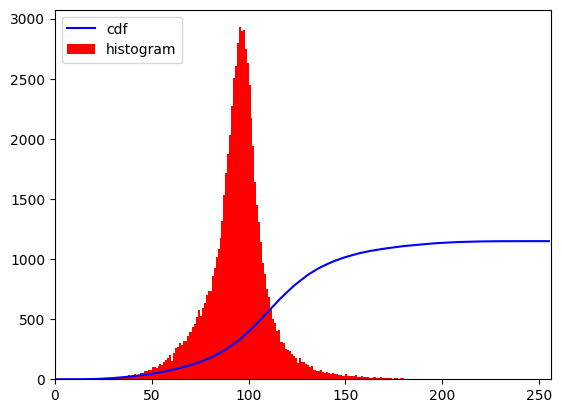

In [26]:
hist,bins = np.histogram(cl1.flatten(),256,[0,256])
 
cdf = hist.cumsum()
cdf_normalized = cdf * float(hist.max()) / cdf.max()
 
plt.plot(cdf_normalized, color = 'b')
plt.hist(img.flatten(),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')
plt.show()

In [27]:
classifier = TreeOfLifeClassifier(device='cpu')

# Use the saved JPEG for classification
prediction_ary = classifier.predict('/kaggle/working/clahe_2.jpg', rank=Rank.SPECIES)

# Convert to pandas dataframe
df_species = pd.DataFrame(prediction_ary)
df_species

100%|██████████| 1/1 [00:01<00:00,  1.27s/images]


,file_name,kingdom,phylum,class,order,family,genus,species_epithet,species,common_name,score
0,/kaggle/working/clahe_2.jpg,Animalia,Echinodermata,Holothuroidea,Holothuriida,Holothuriidae,Holothuria,princeps,Holothuria princeps,Noble Sea Cucumber,0.275458
1,/kaggle/working/clahe_2.jpg,Animalia,Cnidaria,Anthozoa,Scleractinia,Acroporidae,Acropora,natalensis,Acropora natalensis,,0.101872
2,/kaggle/working/clahe_2.jpg,Animalia,Echinodermata,Crinoidea,Comatulida,Tropiometridae,Tropiometra,magnifica,Tropiometra magnifica,,0.037568
3,/kaggle/working/clahe_2.jpg,Animalia,Echinodermata,Asteroidea,Paxillosida,Astropectinidae,Astropecten,africanus,Astropecten africanus,,0.028540
4,/kaggle/working/clahe_2.jpg,Animalia,Echinodermata,Asteroidea,Valvatida,Oreasteridae,Pentaceraster,regulus,Pentaceraster regulus,spotted seastar,0.028372


# Ideas

- I think that we need to change our labels to the complete taxonomy, in order to compare the loss
- If we do, then the out-of-sample test labels won't be the same
- Incorporate histogram equalization (CLAHE) and gaussian blur 